# Lab - Week 10
### Interpreting Machine Learning Models Using SHAP (Migraine Dataset)
## Objective
- Train a Random Forest classifier on the given migraine dataset.
- Use SHAP (SHapley Additive exPlanations) to identify which features most influence the migraine type classification.
- Interpret feature importance. 
- This lab focuses on identifying which migraine-related features (like Visual, Vertigo, Intensity, Age, etc.) contribute most to predicting migraine types.



In [4]:
#Step 1 – Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import shap
import matplotlib.pyplot as plt

/Users/musman/MDX_MS_DS_&_AI/CST4325/Week10/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
#Step 2 – Load and Prepare the Dataset
# Load the dataset
df = pd.read_excel("migraine dataset.xlsx")

In [8]:
# Preview the data
print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Age  Duration  Frequency  Location  Character  Intensity  Nausea  Vomit  \
0   30         1          5         1          1          2       1      0   
1   50         3          5         1          1          3       1      1   
2   53         2          1         1          1          2       1      1   
3   45         3          5         1          1          3       1      0   
4   53         1          1         1          1          2       1      0   

   Phonophobia  Photophobia  ...  Vertigo  Tinnitus  Hypoacusis  Diplopia  \
0            1            1  ...        0         0           0         0   
1            1            1  ...        1         0           0         0   
2            1            1  ...        0         0           0         0   
3            1            1  ...        1         0           0         0   
4            1            1  ...        0         0           0         0   

   Defect  Ataxia  Conscience  Paresthesia  DPF    

In [9]:
# Check columns
print("\nColumns:", df.columns.tolist())


Columns: ['Age', 'Duration', 'Frequency', 'Location', 'Character', 'Intensity', 'Nausea', 'Vomit', 'Phonophobia', 'Photophobia', 'Visual', 'Sensory', 'Dysphasia', 'Dysarthria', 'Vertigo', 'Tinnitus', 'Hypoacusis', 'Diplopia', 'Defect', 'Ataxia', 'Conscience', 'Paresthesia', 'DPF', 'Type']


In [11]:
# Encode the target column ('Type')
le = LabelEncoder()
y = le.fit_transform(df["Type"].astype(str))

# Define features
X = df.drop(columns=["Type"])

# Ensure all features are numeric
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

In [12]:
#Step 3 – Split Data into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (320, 23)
Test set size: (80, 23)


In [13]:
#Step 4 – Train Random Forest Model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
#Step 5 – Apply SHAP for Model Interpretability
# Initialize SHAP explainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values for the test set
shap_values = explainer(X_test)


Top features influencing migraine predictions:


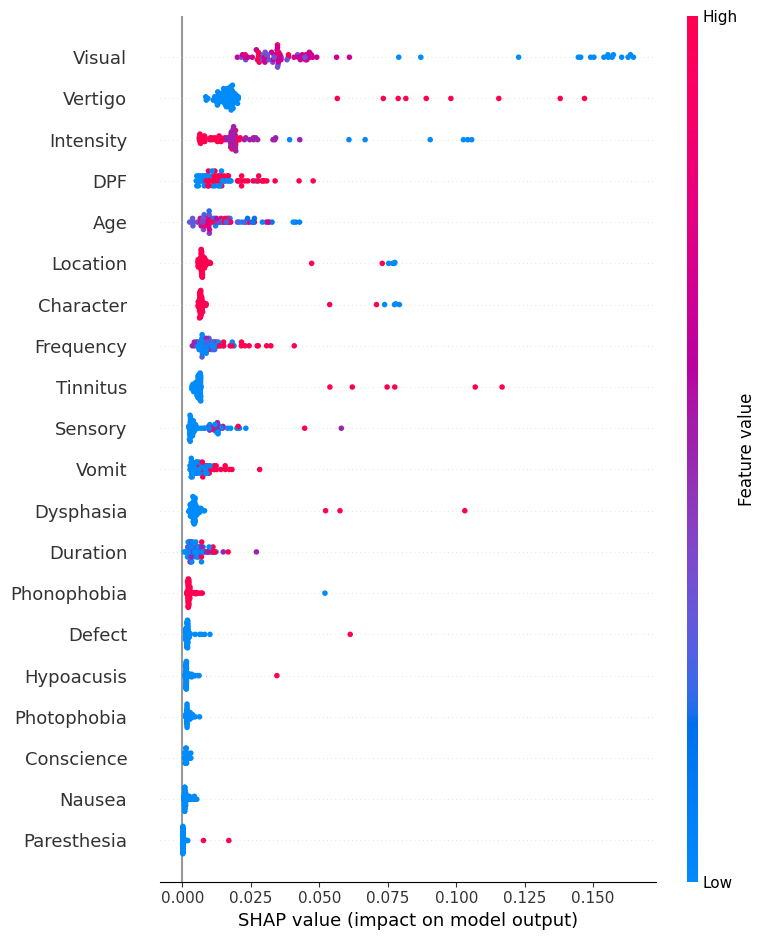

In [15]:
#Step 6 – Visualize Feature Importance
# For multi-class models, average SHAP values across classes
if shap_values.values.ndim == 3:
    shap_values_2d = np.mean(np.abs(shap_values.values), axis=2)
else:
    shap_values_2d = shap_values.values

# Plot global feature importance
print("Top features influencing migraine predictions:")
shap.summary_plot(shap_values_2d, X_test, feature_names=X_test.columns)



In [16]:
#Step 7 – Numerical Feature Ranking
# Get mean absolute SHAP value for each feature
importance = np.mean(np.abs(shap_values_2d), axis=0)
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance
})
feature_importance.sort_values(by="Importance", ascending=False, inplace=True)

print("\nFeature importance ranking:")
print(feature_importance)



Feature importance ranking:
        Feature  Importance
10       Visual    0.056989
14      Vertigo    0.025047
5     Intensity    0.022375
22          DPF    0.015209
0           Age    0.014958
3      Location    0.011983
4     Character    0.011697
2     Frequency    0.011531
15     Tinnitus    0.011502
11      Sensory    0.009085
7         Vomit    0.007400
12    Dysphasia    0.006923
1      Duration    0.005687
8   Phonophobia    0.003216
18       Defect    0.002861
16   Hypoacusis    0.002254
9   Photophobia    0.002142
20   Conscience    0.001445
6        Nausea    0.001232
21  Paresthesia    0.000571
17     Diplopia    0.000499
13   Dysarthria    0.000362
19       Ataxia    0.000000


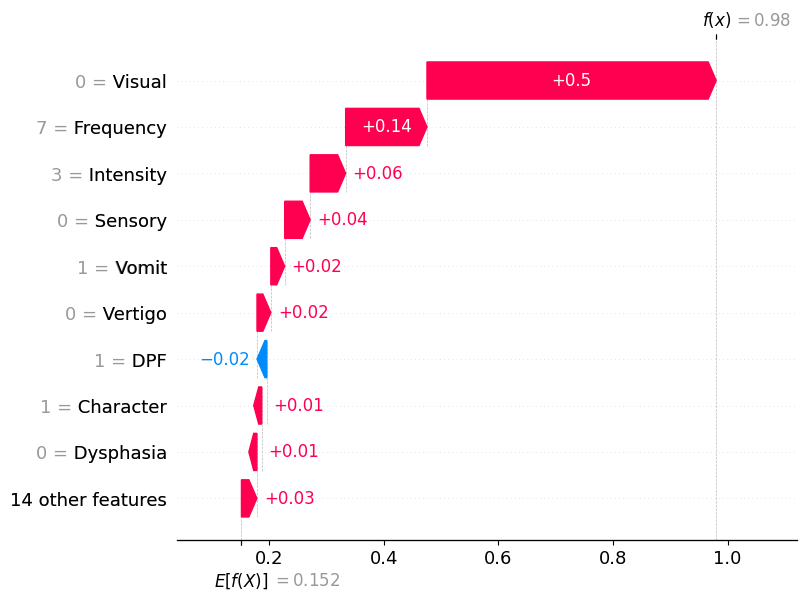

In [17]:
#Step 8 – Individual Prediction Explanation (Optional)
# Pick one sample (first row)
sample_index = 0
pred_class = rf.predict(X_test.iloc[[sample_index]])[0]

# Visualize how each feature contributed to this prediction
if shap_values.values.ndim == 3:
    shap.plots.waterfall(shap_values[sample_index, :, pred_class])
else:
    shap.plots.waterfall(shap_values[sample_index])

### Questions to answer: 
#### 1) Which features have the highest impact on predicting migraine type?
#### Answer: Visual

#### 2) How does the colour help interpret feature influence?
#### Answer: The colour indicates the feature value (red for high, blue for low), showing how different values of a feature influence the prediction.

#### 3) Are the top-ranked features clinically relevant indicators of migraine?
#### Answer: Yes, features like Visual and Vertigo are clinically relevant as they are common symptoms associated with migraines.

#### 4) How might removing low-impact features simplify the model without losing accuracy?
#### Answer: Removing low-impact features can reduce model complexity and improve interpretability while maintaining similar accuracy, as these features contribute little to the prediction.
